In [7]:
from hist_demo import HistogramAccel
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'counts')

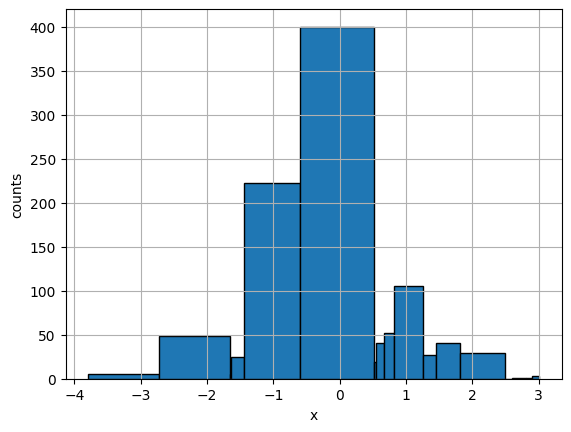

In [12]:
ndata = 1024
nbins = 16
bin_edges = np.random.uniform(-3,3,nbins)
bin_edges.sort()
data = np.random.normal(0,1,ndata)

bin_index = np.searchsorted(bin_edges, data, side="right")
counts = np.bincount(bin_index, minlength=nbins).astype(np.uint32, copy=False)


# Plot a bar graph of the counts with the bin edges as x values
# The width of each bar is the distance between the bin edges i and i+1
# 1. Determine widths for the "Underflow" and "Overflow"
# We'll use the width of the nearest internal neighbor
w_first = bin_edges[1] - bin_edges[0]
w_last = bin_edges[-1] - bin_edges[-2]

# 2. Create extended edges
# [ (edge0 - width), edge0, edge1, ..., edgeN-1, (edgeN-1 + width) ]
ext_edges = np.concatenate([
    [bin_edges[0] - w_first], 
    bin_edges, 
    [bin_edges[-1] + w_last]
])

# 3. Calculate all widths (size will be n+1, matching counts)
widths = np.diff(ext_edges)

# 4. Plot
# We use ext_edges[:-1] as the left start points
plt.bar(ext_edges[:-1], counts, width=widths, align='edge', edgecolor='black')
plt.grid()
plt.xlabel('x')
plt.ylabel('counts')

# Optional: Set custom x-ticks to clarify the under/over bins
#labels = [f"<{bin_edges[0]}"] + [str(e) for e in bin_edges] + [f">={bin_edges[-1]}"]
#plt.xticks(ext_edges, labels=labels)


In [5]:
bin_edges.shape

(32,)